In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv("Housing.csv")
data

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


In [3]:
data.shape

(545, 13)

In [4]:
data.size

7085

In [5]:
data.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [7]:
data.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [8]:
data.duplicated().sum()

np.int64(0)

In [9]:
# Encoding Categorical Variables

# Label Encoding for yes/no columns
yes_no_cols = [
    'mainroad',
    'guestroom',
    'basement',
    'hotwaterheating',
    'airconditioning',
    'prefarea'
]


for col in yes_no_cols:
    data[col] = (
        data[col]
        .astype(str)
        .str.strip()
        .str.lower()
        .map({'yes': 1, 'no': 0})
    )


# One-Hot Encoding

# lr
data_lr = pd.get_dummies(
    data.copy(),
    columns=['furnishingstatus'],
    drop_first=True
)

# rf,dt,ridge,xg
data_tree = pd.get_dummies(
    data.copy(),
    columns=['furnishingstatus'],
    drop_first=False
)

In [10]:
print(data[yes_no_cols].head())

   mainroad  guestroom  basement  hotwaterheating  airconditioning  prefarea
0         1          0         0                0                1         1
1         1          0         0                0                1         0
2         1          0         1                0                0         1
3         1          0         1                0                1         1
4         1          1         1                0                1         0


# Models

### 1) RandomFRandomForestRegressor

In [11]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error



X = data_tree.drop('price', axis = 1)
y = data['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=10,
    min_samples_split=5,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print('R2 : ', r2_score(y_test, rf_pred))
print('MAE : ', mean_absolute_error(y_test, rf_pred))

R2 :  0.6092249506709042
MAE :  1028272.9786555007


In [12]:
#Importance of each featue in prediction

import pandas as pd

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

print(
    importance.sort_values(
        by='Importance',
        ascending=False
    )
)

                            Feature  Importance
0                              area    0.476362
2                         bathrooms    0.167122
8                   airconditioning    0.058644
3                           stories    0.050923
9                           parking    0.050692
1                          bedrooms    0.043119
13     furnishingstatus_unfurnished    0.036789
6                          basement    0.031120
10                         prefarea    0.028088
7                   hotwaterheating    0.018762
5                         guestroom    0.014845
4                          mainroad    0.008677
11       furnishingstatus_furnished    0.007842
12  furnishingstatus_semi-furnished    0.007014


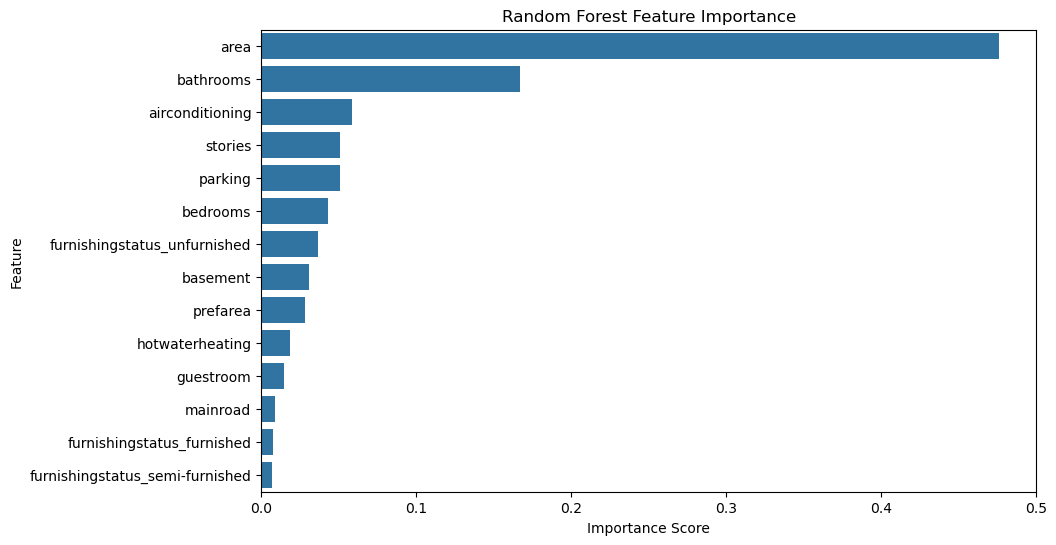

In [13]:
#Visual reoresentation of importance of each feature

import matplotlib.pyplot as plt
import seaborn as sns

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=importance,
    x='Importance',
    y='Feature'
)

plt.title('Random Forest Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Feature')

plt.show()

### 2) DecisionTreeRegressor 

In [14]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_absolute_error

X = data_tree.drop('price', axis = 1)
y = data['price']

dt = DecisionTreeRegressor(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("R2 Score :", r2_score(y_test, dt_pred))
print("MAE :", mean_absolute_error(y_test, dt_pred))

R2 Score : 0.40695858460408285
MAE : 1280133.0275229358


### 3) Ridge



In [15]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)

ridge.fit(X_train, y_train)

ridge_pred = ridge.predict(X_test)

print("R2:", r2_score(y_test, ridge_pred))
print("MAE:", mean_absolute_error(y_test, ridge_pred))


R2: 0.6524271598634787
MAE: 970589.5047431181


### 4) XGBRegressor

In [16]:
pip install xgboost

   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.3/69.5 MB ? eta -:--:--
    --------------------------------------- 1.0/69.5 MB 3.9 MB/s eta 0:00:18
   - -------------------------------------- 1.8/69.5 MB 4.1 MB/s eta 0:00:17
   - -------------------------------------- 2.9/69.5 MB 4.2 MB/s eta 0:00:16
   -- ------------------------------------- 3.7/69.5 MB 4.3 MB/s eta 0:00:16
   -- ------------------------------------- 4.7/69.5 MB 4.3 MB/s eta 0:00:15
   -- ------------------------------------- 5.0/69.5 MB 4.3 MB/s eta 0:00:16
   --- ------------------------------------ 5.5/69.5 MB 3.6 MB/s eta 0:00:18
   --- ------------------------------------ 5.8/69.5 MB 3.4 MB/s eta 0:00:19
   --- ------------------------------------ 6.3/69.5 MB 3.3 MB/s eta 0:00:20
   --- ------------------------------------ 6.6/69.5 MB 3.2 MB/s eta 0:00:20
   ---- ----------------------------------- 7.1/69.5 MB 2.9 MB/s eta 0:00:22
   ---- -----

In [17]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

print("R2:", r2_score(y_test, xgb_pred))
print("MAE:", mean_absolute_error(y_test, xgb_pred))

R2: 0.6003818511962891
MAE: 1030458.0


### 5) LinearRegression 

In [18]:
from sklearn.linear_model import LinearRegression


X = data_lr.drop('price', axis = 1)
y = data['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

lr = LinearRegression()

lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

print("R2 Score : ", r2_score(y_test, y_pred))
print("MAE : ", mean_absolute_error(y_test, y_pred))

R2 Score :  0.6529242642153186
MAE :  970043.4039201634


In [19]:
#Importance of each featue in prediction

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

lr = LinearRegression()
lr.fit(X_scaled, y)

importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr.coef_
})

importance['Importance'] = abs(importance['Coefficient'])

print(
    importance.sort_values(
        by='Importance',
        ascending=False
    )
)

                            Feature    Coefficient     Importance
0                              area  529330.603637  529330.603637
2                         bathrooms  495817.709085  495817.709085
8                   airconditioning  401991.910116  401991.910116
3                           stories  390748.265675  390748.265675
10                         prefarea  276197.743672  276197.743672
9                           parking  238532.391199  238532.391199
12     furnishingstatus_unfurnished -192857.242507  192857.242507
7                   hotwaterheating  178965.103239  178965.103239
6                          basement  167040.771638  167040.771638
4                          mainroad  146735.429744  146735.429744
5                         guestroom  114950.329358  114950.329358
1                          bedrooms   84642.788854   84642.788854
11  furnishingstatus_semi-furnished  -22847.006837   22847.006837


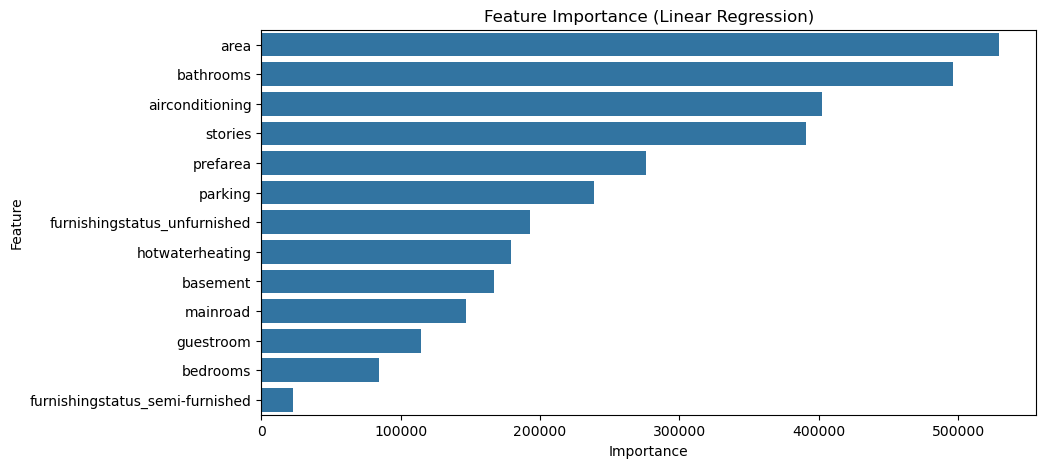

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,5))

sns.barplot(
    data=importance,
    x='Importance',
    y='Feature'
)

plt.title("Feature Importance (Linear Regression)")
plt.show()

In [21]:
top_features = [
    'area',
    'bathrooms',
    'stories',
    'parking',
    'airconditioning'
]

X = data[top_features]
y = data['price']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

lr1 = LinearRegression()

lr1.fit(X_train, y_train)

y_pred = lr1.predict(X_test)

print("R2 Score : ", r2_score(y_test, y_pred))
print("MAE : ", mean_absolute_error(y_test, y_pred))

R2 Score :  0.5837272890591467
MAE :  1100985.2503798364


In [25]:
import pickle

# Save model
with open("house_price_model.pkl", "wb") as f:
    pickle.dump(lr, f)

print("Model saved successfully!")

Model saved successfully!


In [26]:
import pickle

with open("house_price_model.pkl", "rb") as f:
    model = pickle.load(f)

In [33]:
import pandas as pd

new_house = pd.DataFrame({
    'area': [3000],
    'bedrooms': [3],
    'bathrooms': [2],
    'stories': [2],
    'mainroad': [1],
    'guestroom': [0],
    'basement': [0],
    'hotwaterheating': [0],
    'airconditioning': [1],
    'parking': [1],
    'prefarea': [0],
    'furnishingstatus_semi-furnished': [0],
    'furnishingstatus_unfurnished': [1]
})

price = lr.predict(new_house)

print(f"Predicted Price: ₹{price[0]:,.0f}")

Predicted Price: ₹1,595,380,003


C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
